# Mediterranean Sea — surface temperature map

Demonstrates the **regional-reanalysis map pattern**: pull one summer
day of the Mediterranean physics reanalysis potential temperature
(`thetao`), clipped to the surface layer, and render the basin-wide SST
field.

Dataset `cmems_mod_med_phy-temp_my_4.2km_P1D-m` is a multi-year
reanalysis on a ~4 km grid (stable historical coverage, so a fixed date
works). It is 4-D, so we clip `minimum_depth`/`maximum_depth` to the top
few metres to fetch just the surface field.

Reads credentials from `COPERNICUSMARINE_SERVICE_USERNAME` /
`COPERNICUSMARINE_SERVICE_PASSWORD`.

In [1]:
import os
from pathlib import Path

import xarray as xr
from pyramids.netcdf import NetCDF

from earthlens import EarthLens
from earthlens.cmems import Catalog

OUT_DIR = Path('data/cmems-medsst')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'cmems_mod_med_phy-temp_my_4.2km_P1D-m'
DAY = '2020-08-15'  # mid-summer, strong basin-wide SST gradient

ds_meta = Catalog().get_dataset(DATASET_ID)
print(f'{DATASET_ID}: domain={ds_meta.domain}, cadence={ds_meta.cadence}')
print('thetao units:', ds_meta.variables['thetao'].units)

2026-05-20 19:43:34 | INFO | pyramids.base.config | Logging is configured.


cmems_mod_med_phy-temp_my_4.2km_P1D-m: domain=mediterranean, cadence=daily
thetao units: degrees_C


## Download one day, surface layer, whole basin

In [2]:
el = EarthLens(
    data_source='cmems',
    start=DAY,
    end=DAY,
    cadence='daily',
    dataset=DATASET_ID,
    variables=['thetao'],
    aoi=[-6.0, 30.0, 36.5, 46.0],
    path=str(OUT_DIR),
    minimum_depth=0.0,
    maximum_depth=2.0,
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = el.download()
print(paths)

INFO - 2026-05-20T17:43:37Z - Checking if credentials are valid.


2026-05-20 17:43:37 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T17:43:38Z - Valid credentials from input username and password.


2026-05-20 17:43:38 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 19:43:38.037 | INFO     | earthlens.cmems.backend:_subset_one:458 - Requesting CMEMS subset for 'cmems_mod_med_phy-temp_my_4.2km_P1D-m' variables=['thetao'] → cmems_mod_med_phy-temp_my_4.2km_P1D-m.nc


...

2026-05-20 17:43:38 | WARNING | copernicusmarine | Some of your subset selection [0.0, 2.0] for the depth dimension exceed the dataset coordinates [1.0182366371154785, 5754.0439453125]


INFO - 2026-05-20T17:43:40Z - Total size of the download: 1.49 MB.


2026-05-20 17:43:40 | INFO | copernicusmarine | Total size of the download: 1.49 MB.


2026-05-20 19:43:40.589 | INFO     | earthlens.cmems.backend:download:326 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-medsst


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-medsst/cmems_mod_med_phy-temp_my_4.2km_P1D-m.nc')]


## Open and reduce to a 2-D surface field

In [3]:
import numpy as np

nc = NetCDF.read_file(str(paths[0]), read_only=True)
ds = xr.decode_cf(nc.to_xarray())
nc.close()
print('dims:', dict(ds.sizes))
# Top model level, single day -> 2-D (latitude, longitude).
sst = ds['thetao'].isel(time=0, depth=0)
valid = sst.values[~np.isnan(sst.values)]
print(
    f'surface thetao min/mean/max: {valid.min():.1f} / {valid.mean():.1f} / {valid.max():.1f} degrees_C'
)

dims: {'time': 1, 'depth': 1, 'latitude': 380, 'longitude': 1016}
surface thetao min/mean/max: 19.4 / 27.2 / 31.3 degrees_C


## Map the surface temperature

Warm eastern-basin / Levantine waters versus the cooler Gulf of Lions
and Aegean — the classic August Mediterranean SST signature.

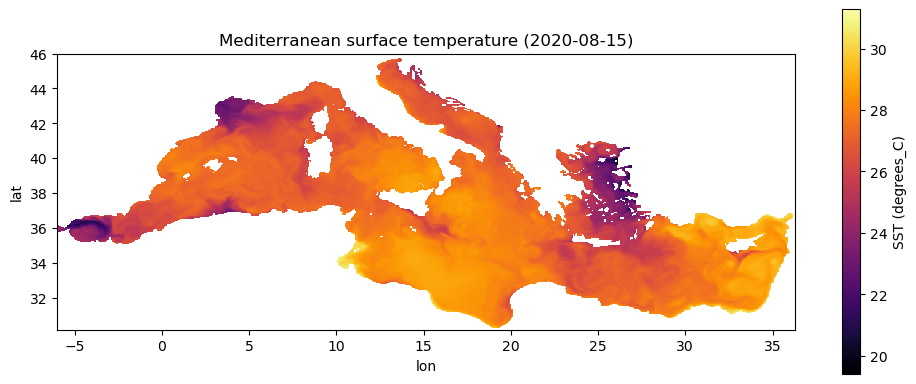

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(
    sst['longitude'].values,
    sst['latitude'].values,
    sst.values,
    cmap='inferno',
    shading='auto',
)
fig.colorbar(mesh, ax=ax, label='SST (degrees_C)')
ax.set_title(f'Mediterranean surface temperature ({DAY})')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.set_aspect('equal')
fig.tight_layout()